# ECON5380 Group Project: Group 2 (Ethereum Price Forecasting)

**Objective:** Forecast ETH/USD price for the next 3 months using multiple models, run scenario and sensitivity analysis, and interpret the risk.

**Deliverables in this notebook:**
1. Data acquisition and EDA
2. Six forecasting models (Naive, ARIMA, SARIMAX, GARCH, XGBoost, LSTM)
3. Model performance comparison (RMSE / MAE / MAPE / Directional Accuracy)
4. Three scenario forecasts (Bull, Base, Bear) + one Black Swan
5. Sensitivity analysis on key drivers (BTC, volatility, rates, volume)
6. Risk interpretation


## 1. Setup

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from arch import arch_model

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
import xgboost as xgb

# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout

np.random.seed(42)

## 2. Data Acquisition

Pulling daily ETH/USD from Yahoo Finance, plus BTC/USD and macro context (DXY, ^TNX) for feature engineering and scenario work.

In [7]:
# Pull ~5 years of daily data
END = pd.Timestamp.today().normalize()
START = END - pd.DateOffset(years=5)

tickers = {
    'ETH': 'ETH-USD',
    'BTC': 'BTC-USD',
    'DXY': 'DX-Y.NYB',      # Dollar index
    'TNX': '^TNX',          # 10Y Treasury yield
    'VIX': '^VIX',          # Equity vol
    'SPY': 'SPY'            # Equity proxy
}

raw = {}
for name, tkr in tickers.items():
    df = yf.download(tkr, start=START, end=END, progress=False, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    raw[name] = df

eth = raw['ETH'].copy()
print(f'ETH rows: {len(eth)} | range: {eth.index.min().date()} -> {eth.index.max().date()}')
eth.tail()

ETH rows: 1826 | range: 2021-05-13 -> 2026-05-12


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-05-08,2306.972168,2320.692139,2265.833252,2291.075684,20013463010
2026-05-09,2326.727295,2336.927002,2300.544922,2307.069580,12217205123
2026-05-10,2369.043945,2381.263916,2313.127197,2326.744385,19587186882
2026-05-11,2339.360840,2374.303467,2305.080811,2369.193359,15525623296
2026-05-12,2274.643555,2339.690430,2256.419434,2339.287109,16145394773


In [8]:
# Build combined daily panel on ETH calendar
panel = pd.DataFrame(index=eth.index)
panel['ETH_close']  = eth['Close']
panel['ETH_volume'] = eth['Volume']
panel['ETH_high']   = eth['High']
panel['ETH_low']    = eth['Low']

for k in ['BTC', 'DXY', 'TNX', 'VIX', 'SPY']:
    panel[f'{k}_close'] = raw[k]['Close']

# Forward fill macro series (weekends/holidays)
panel = panel.ffill().dropna()
panel.tail()

,ETH_close,ETH_volume,ETH_high,ETH_low,BTC_close,DXY_close,TNX_close,VIX_close,SPY_close
Date,,,,,,,,,
2026-05-08,2306.972168,20013463010,2320.692139,2265.833252,80186.765625,97.839996,4.364,17.190001,737.619995
2026-05-09,2326.727295,12217205123,2336.927002,2300.544922,80664.367188,97.839996,4.364,17.190001,737.619995
2026-05-10,2369.043945,19587186882,2381.263916,2313.127197,82138.929688,97.839996,4.364,17.190001,737.619995
2026-05-11,2339.360840,15525623296,2374.303467,2305.080811,81728.296875,97.940002,4.410,18.379999,739.299988
2026-05-12,2274.643555,16145394773,2339.690430,2256.419434,80477.492188,98.290001,4.463,17.990000,738.179993


## 3. Exploratory Analysis

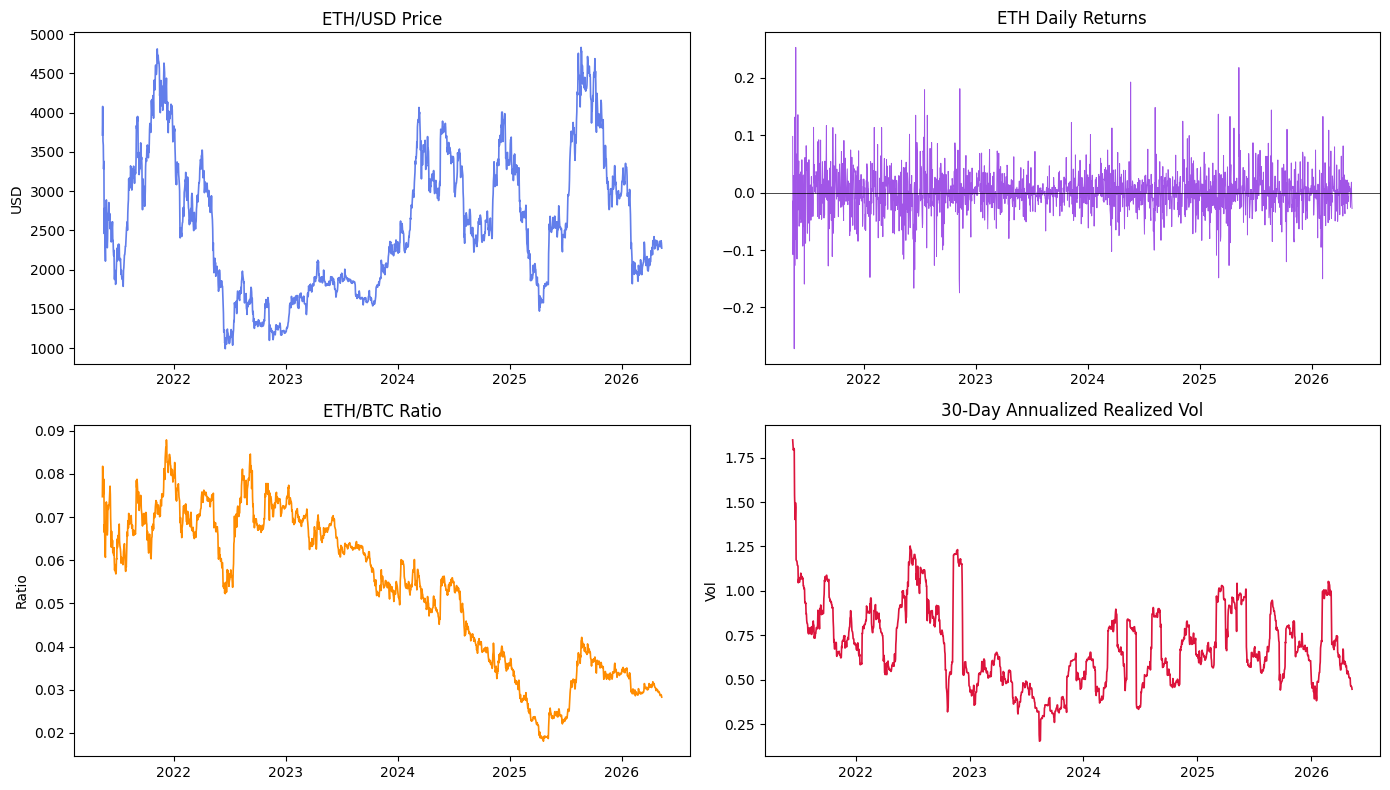

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(panel.index, panel['ETH_close'], color='#627EEA', lw=1.2)
axes[0, 0].set_title('ETH/USD Price'); axes[0, 0].set_ylabel('USD')

eth_ret = panel['ETH_close'].pct_change().dropna()
axes[0, 1].plot(eth_ret.index, eth_ret, color='#8a2be2', lw=0.7, alpha=0.8)
axes[0, 1].set_title('ETH Daily Returns'); axes[0, 1].axhline(0, color='k', lw=0.5)

axes[1, 0].plot(panel.index, panel['ETH_close'] / panel['BTC_close'], color='darkorange', lw=1.2)
axes[1, 0].set_title('ETH/BTC Ratio'); axes[1, 0].set_ylabel('Ratio')

vol30 = eth_ret.rolling(30).std() * np.sqrt(365)
axes[1, 1].plot(vol30.index, vol30, color='crimson', lw=1.2)
axes[1, 1].set_title('30-Day Annualized Realized Vol'); axes[1, 1].set_ylabel('Vol')

plt.tight_layout(); plt.show()

In [12]:
# Stationarity check
def adf_summary(series, name):
    series = series.dropna()
    stat, p, *_ = adfuller(series)
    return {'series': name, 'ADF stat': stat, 'p-value': p, 'stationary?': p < 0.05}

results = [
    adf_summary(panel['ETH_close'], 'ETH price'),
    adf_summary(panel['ETH_close'].pct_change(), 'ETH returns'),
    adf_summary(np.log(panel['ETH_close']).diff(), 'ETH log returns'),
]
pd.DataFrame(results)

,series,ADF stat,p-value,stationary?
0,ETH price,-2.697301,0.074506,False
1,ETH returns,-44.690241,0.000000,True
2,ETH log returns,-44.555742,0.000000,True


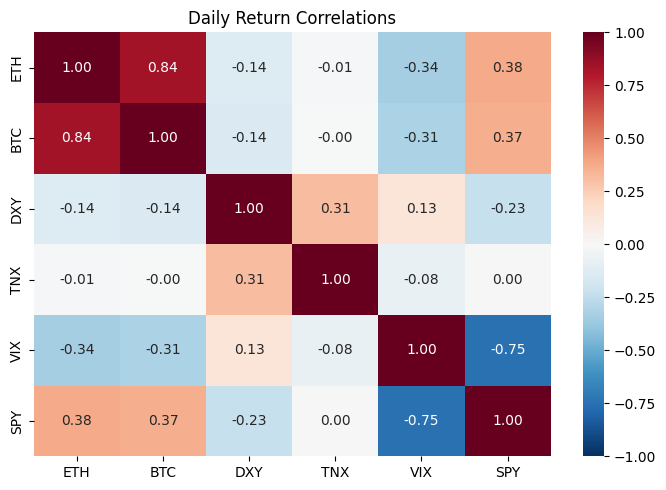

In [15]:
# Correlation with other assets (returns)
ret_panel = panel[['ETH_close','BTC_close','DXY_close','TNX_close','VIX_close','SPY_close']].pct_change().dropna()
ret_panel.columns = ['ETH','BTC','DXY','TNX','VIX','SPY']

plt.figure(figsize=(7, 5))
sns.heatmap(ret_panel.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Daily Return Correlations'); plt.tight_layout(); plt.show()

## 4. Feature Engineering

Target: next-day ETH close. Features include lagged returns, rolling stats, BTC features, and macro context.

In [16]:
def make_features(df):
    out = pd.DataFrame(index=df.index)
    p = df['ETH_close']; v = df['ETH_volume']

    # Price and returns
    out['close']   = p
    out['log_ret'] = np.log(p).diff()
    for lag in [1, 2, 3, 5, 10, 21]:
        out[f'ret_lag_{lag}'] = out['log_ret'].shift(lag)

    # Rolling stats
    for w in [5, 10, 21, 63]:
        out[f'roll_mean_{w}'] = out['log_ret'].rolling(w).mean()
        out[f'roll_std_{w}']  = out['log_ret'].rolling(w).std()
    out['mom_21']  = p.pct_change(21)
    out['mom_63']  = p.pct_change(63)
    out['rsi_14']  = compute_rsi(p, 14)

    # Volume
    out['vol_z_21'] = (v - v.rolling(21).mean()) / v.rolling(21).std()
    out['hl_range'] = (df['ETH_high'] - df['ETH_low']) / p

    # Cross-asset
    out['btc_ret']    = np.log(df['BTC_close']).diff()
    out['btc_ret_5']  = np.log(df['BTC_close']).diff(5)
    out['eth_btc']    = df['ETH_close'] / df['BTC_close']
    out['dxy_ret']    = np.log(df['DXY_close']).diff()
    out['tnx_chg']    = df['TNX_close'].diff()
    out['vix_chg']    = df['VIX_close'].pct_change()
    out['spy_ret']    = np.log(df['SPY_close']).diff()

    # Target = next-day log return
    out['target_logret'] = out['log_ret'].shift(-1)
    out['target_close']  = p.shift(-1)
    return out

def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0).rolling(period).mean()
    loss = -delta.where(delta < 0, 0.0).rolling(period).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

feat = make_features(panel).dropna()
print(f'Feature matrix: {feat.shape}')
feat.tail(3)

Feature matrix: (1762, 30)


,close,log_ret,ret_lag_1,ret_lag_2,ret_lag_3,ret_lag_5,ret_lag_10,ret_lag_21,roll_mean_5,roll_std_5,...,hl_range,btc_ret,btc_ret_5,eth_btc,dxy_ret,tnx_chg,vix_chg,spy_ret,target_logret,target_close
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-09,2326.727295,0.008527,0.006901,-0.025721,-0.004406,0.010609,-0.015851,-0.029327,-0.001684,0.014375,...,0.015637,0.005938,0.010424,0.028845,0.000000,0.000,0.000000,0.000000,0.018024,2369.043945
2026-05-10,2369.043945,0.018024,0.008527,0.006901,-0.025721,0.006282,0.001257,-0.037345,0.000665,0.016763,...,0.028761,0.018115,0.014864,0.028842,0.000000,0.000,0.000000,0.000000,-0.012609,2339.360840
2026-05-11,2339.360840,-0.012609,0.018024,0.008527,0.006901,-0.004406,0.017069,0.021963,-0.000976,0.017755,...,0.029590,-0.005012,0.003687,0.028624,0.001022,0.046,0.069226,0.002275,-0.028054,2274.643555


## 5. Train / Test Split

Time-series split, no leakage. Hold out the last ~120 trading days as the test set so we can score every model on the same out-of-sample window. The final 3-month forecast is a separate forward projection.

In [17]:
TEST_DAYS = 120
train = feat.iloc[:-TEST_DAYS].copy()
test  = feat.iloc[-TEST_DAYS:].copy()

print(f'Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} rows)')
print(f'Test : {test.index.min().date()} -> {test.index.max().date()} ({len(test)} rows)')

Train: 2021-07-15 -> 2026-01-11 (1642 rows)
Test : 2026-01-12 -> 2026-05-11 (120 rows)


In [18]:
# Evaluation helper: operate on price-level forecasts
def score(actual, predicted, name):
    actual, predicted = np.array(actual), np.array(predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    # Directional accuracy on day-over-day moves
    a_dir = np.sign(np.diff(actual))
    p_dir = np.sign(np.diff(predicted))
    dir_acc = (a_dir == p_dir).mean() * 100
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'Dir Acc (%)': dir_acc}

scoreboard = []
predictions = {}     # model_name -> predicted price series aligned with test index
ACTUAL = test['target_close'].values
TEST_IDX = test.index

## 6. Forecasting Models

### 6.1 Naive (random walk): baseline

In [21]:
# Tomorrow's price = today's price
naive_pred = test['close'].values
predictions['Naive'] = naive_pred
scoreboard.append(score(ACTUAL, naive_pred, 'Naive'))
print('Naive baseline scored.')

Naive baseline scored.


### 6.2 ARIMA on log returns

In [22]:
# Walk-forward ARIMA(1,0,1) on log returns -> convert to price
arima_pred = np.zeros(len(test))
history = list(train['log_ret'].values)

for i, dt in enumerate(test.index):
    try:
        m = ARIMA(history, order=(1, 0, 1)).fit()
        fcst_ret = m.forecast(steps=1)[0]
    except Exception:
        fcst_ret = 0.0
    prev_close = panel['ETH_close'].loc[dt]    # today's close (info available at close-of-day)
    arima_pred[i] = prev_close * np.exp(fcst_ret)
    history.append(test['log_ret'].iloc[i])

predictions['ARIMA(1,0,1)'] = arima_pred
scoreboard.append(score(ACTUAL, arima_pred, 'ARIMA(1,0,1)'))
print('ARIMA scored.')

ARIMA scored.


### 6.3 SARIMAX with exogenous regressors

In [23]:
# ARIMAX with BTC return and VIX change as exogenous drivers
exog_cols = ['btc_ret', 'vix_chg', 'dxy_ret']
sarimax_pred = np.zeros(len(test))
hist_y = list(train['log_ret'].values)
hist_x = train[exog_cols].values.tolist()

for i, dt in enumerate(test.index):
    try:
        m = SARIMAX(hist_y, exog=np.array(hist_x), order=(1, 0, 1),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        x_next = test[exog_cols].iloc[i].values.reshape(1, -1)
        fcst_ret = m.forecast(steps=1, exog=x_next)[0]
    except Exception:
        fcst_ret = 0.0
    prev_close = panel['ETH_close'].loc[dt]
    sarimax_pred[i] = prev_close * np.exp(fcst_ret)
    hist_y.append(test['log_ret'].iloc[i])
    hist_x.append(test[exog_cols].iloc[i].values.tolist())

predictions['SARIMAX'] = sarimax_pred
scoreboard.append(score(ACTUAL, sarimax_pred, 'SARIMAX'))
print('SARIMAX scored.')

SARIMAX scored.


### 6.4 GARCH(1,1): volatility + mean model

GARCH gives us conditional volatility for risk management. The mean equation also produces a return forecast which we convert to price.

In [24]:
# Scale returns to percent to help the optimizer
ret_pct_train = train['log_ret'].values * 100
ret_pct_test  = test['log_ret'].values * 100

garch_pred = np.zeros(len(test))
garch_vol  = np.zeros(len(test))
history = list(ret_pct_train)

for i, dt in enumerate(test.index):
    try:
        am = arch_model(history, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='t')
        res = am.fit(disp='off', show_warning=False)
        fc = res.forecast(horizon=1, reindex=False)
        fcst_ret_pct = fc.mean.values[-1, 0]
        fcst_var_pct = fc.variance.values[-1, 0]
    except Exception:
        fcst_ret_pct, fcst_var_pct = 0.0, 1.0
    prev_close = panel['ETH_close'].loc[dt]
    garch_pred[i] = prev_close * np.exp(fcst_ret_pct / 100)
    garch_vol[i]  = np.sqrt(fcst_var_pct) / 100
    history.append(ret_pct_test[i])

predictions['GARCH(1,1)'] = garch_pred
scoreboard.append(score(ACTUAL, garch_pred, 'GARCH(1,1)'))
print('GARCH scored.')

GARCH scored.


### 6.5 XGBoost on engineered features

In [26]:
SEED = 42
drop_cols = ['target_logret', 'target_close', 'close']
X_train = train.drop(columns=drop_cols)
y_train = train['target_logret']
X_test  = test.drop(columns=drop_cols)
y_test  = test['target_logret']

xgb_model = xgb.XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
fcst_logret = xgb_model.predict(X_test)
xgb_pred = test['close'].values * np.exp(fcst_logret)

predictions['XGBoost'] = xgb_pred
scoreboard.append(score(ACTUAL, xgb_pred, 'XGBoost'))
print('XGBoost scored.')

XGBoost scored.


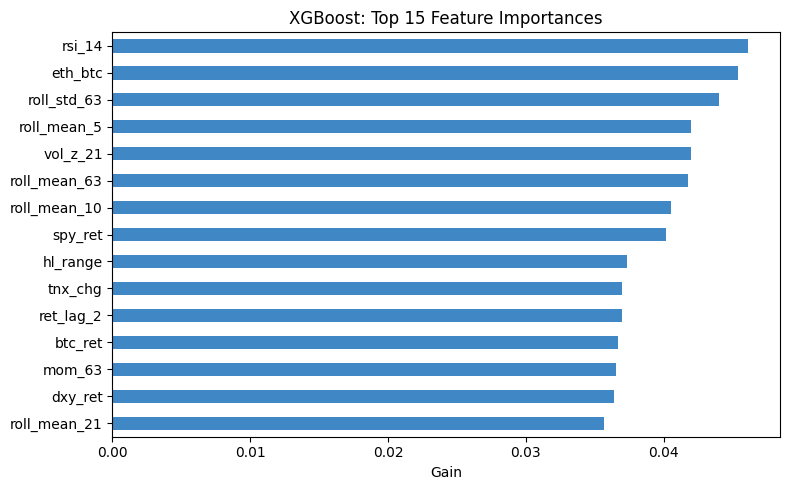

In [27]:
# Feature importance
imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
imp[::-1].plot(kind='barh', color='#3F88C5')
plt.title('XGBoost: Top 15 Feature Importances')
plt.xlabel('Gain'); plt.tight_layout(); plt.show()

### 6.6 LSTM on multivariate sequences

In [28]:
SEQ_LEN = 30
lstm_feats = ['log_ret','ret_lag_1','ret_lag_5','roll_std_21','rsi_14',
              'btc_ret','vix_chg','dxy_ret','vol_z_21']

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_all_scaled = scaler_X.fit_transform(feat[lstm_feats])
y_all_scaled = scaler_y.fit_transform(feat[['target_logret']])

def windowize(X, y, seq):
    Xs, ys = [], []
    for i in range(seq, len(X)):
        Xs.append(X[i-seq:i]); ys.append(y[i])
    return np.array(Xs), np.array(ys)

Xw, yw = windowize(X_all_scaled, y_all_scaled, SEQ_LEN)
# Align with overall train/test cut
split = len(feat) - TEST_DAYS - SEQ_LEN
X_tr, X_te = Xw[:split], Xw[split:]
y_tr, y_te = yw[:split], yw[split:]
print('LSTM shapes:', X_tr.shape, X_te.shape)

LSTM shapes: (1612, 30, 9) (120, 30, 9)


In [29]:
tf.random.set_seed(SEED)
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, len(lstm_feats))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
es = EarlyStopping(patience=10, restore_best_weights=True)
hist = model.fit(X_tr, y_tr, validation_split=0.1, epochs=60, batch_size=32,
                 callbacks=[es], verbose=0)
print(f'LSTM trained for {len(hist.history["loss"])} epochs.')

NameError: name 'tf' is not defined

In [30]:
yhat_scaled = model.predict(X_te, verbose=0)
yhat_logret = scaler_y.inverse_transform(yhat_scaled).flatten()
# Align: predictions correspond to the LAST TEST_DAYS rows
lstm_pred = test['close'].values * np.exp(yhat_logret[-len(test):])

predictions['LSTM'] = lstm_pred
scoreboard.append(score(ACTUAL, lstm_pred, 'LSTM'))
print('LSTM scored.')

NameError: name 'model' is not defined

## 7. Model Performance Comparison

In [31]:
board = pd.DataFrame(scoreboard).sort_values('RMSE').reset_index(drop=True)
board

,Model,RMSE,MAE,MAPE (%),Dir Acc (%)
0,Naive,85.834779,59.811609,2.638266,50.420168
1,"ARIMA(1,0,1)",85.855300,59.781744,2.636844,51.260504
2,"GARCH(1,1)",85.937579,59.581380,2.629279,53.781513
3,XGBoost,95.673878,67.563308,2.978476,51.260504
4,SARIMAX,110.432244,78.910992,3.507480,57.142857


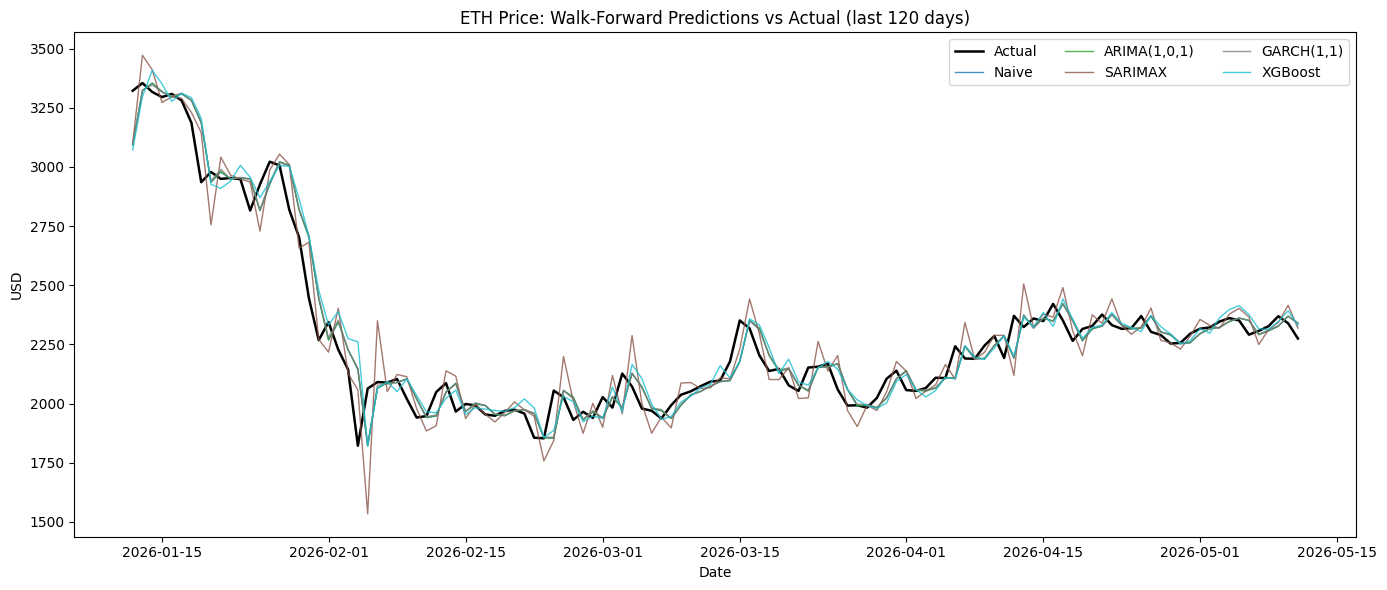

In [32]:
# Plot all model predictions vs actual on test set
plt.figure(figsize=(14, 6))
plt.plot(TEST_IDX, ACTUAL, label='Actual', color='black', lw=1.8)
colors = plt.cm.tab10(np.linspace(0, 1, len(predictions)))
for (name, pred), c in zip(predictions.items(), colors):
    plt.plot(TEST_IDX, pred, label=name, lw=1.0, alpha=0.8, color=c)
plt.title(f'ETH Price: Walk-Forward Predictions vs Actual (last {TEST_DAYS} days)')
plt.xlabel('Date'); plt.ylabel('USD'); plt.legend(ncol=3, loc='best')
plt.tight_layout(); plt.show()

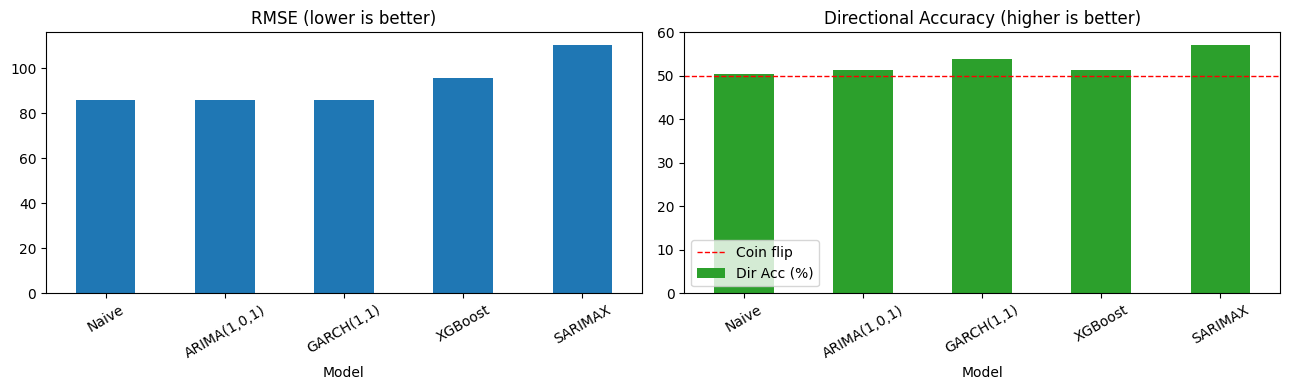

Best by RMSE: Naive


In [33]:
# Bar chart of RMSE
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
board.set_index('Model')['RMSE'].plot(kind='bar', ax=axes[0], color='#1f77b4')
axes[0].set_title('RMSE (lower is better)'); axes[0].tick_params(axis='x', rotation=30)

board.set_index('Model')['Dir Acc (%)'].plot(kind='bar', ax=axes[1], color='#2ca02c')
axes[1].axhline(50, color='red', ls='--', lw=1, label='Coin flip')
axes[1].set_title('Directional Accuracy (higher is better)'); axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(); plt.tight_layout(); plt.show()

best_model = board.iloc[0]['Model']
print(f'Best by RMSE: {best_model}')

## 8. Three-Month Forward Forecast

For the forward path we use a Monte Carlo simulation calibrated on the GARCH conditional volatility and the average drift from the best mean-model. This gives us a distribution rather than a single point, which is critical for risk work and scenario layering.

In [34]:
HORIZON = 63           # ~3 trading months
N_SIM   = 2000

# Calibrate drift and volatility from the most recent 1Y
recent = panel['ETH_close'].pct_change().dropna().tail(252)
mu  = recent.mean()
sig = recent.std()
spot = panel['ETH_close'].iloc[-1]
print(f'Spot: ${spot:,.2f}  |  daily mu: {mu:.4%}  |  daily sigma: {sig:.4%}')

Spot: $2,274.64  |  daily mu: -0.1933%  |  daily sigma: 3.5031%


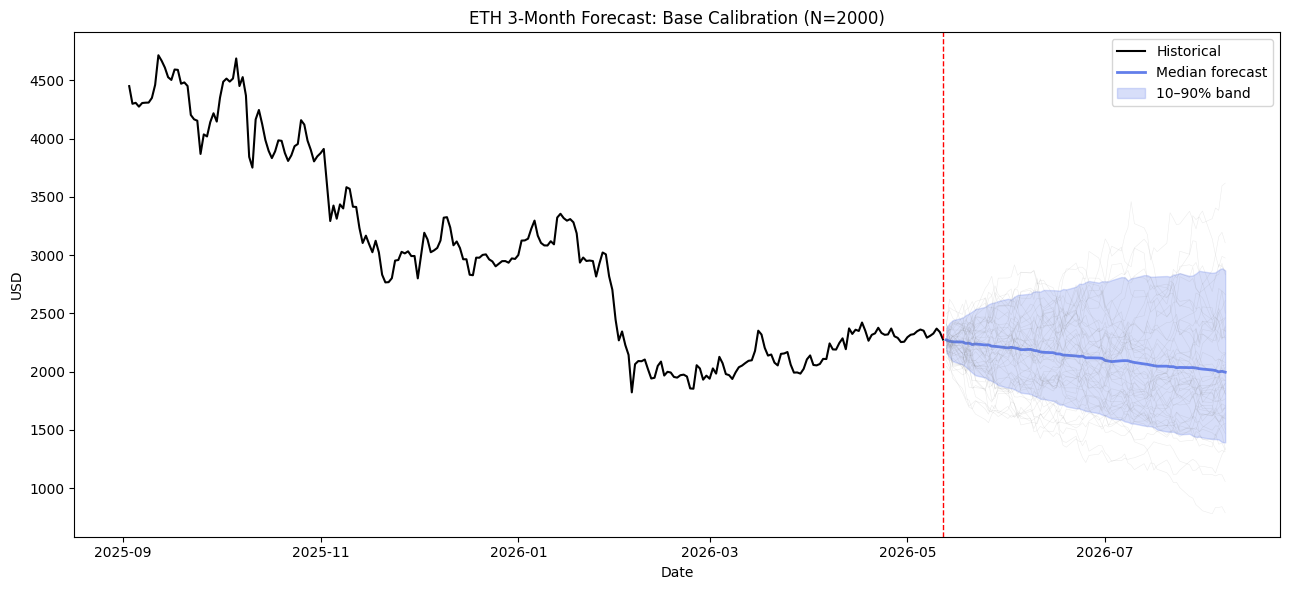

3-month median: $1,995  |  10th: $1,392  |  90th: $2,868


In [35]:
def simulate(spot, mu, sigma, horizon, n_sim, seed=SEED):
    rng = np.random.default_rng(seed)
    shocks = rng.normal(loc=mu, scale=sigma, size=(n_sim, horizon))
    paths = spot * np.exp(np.cumsum(shocks, axis=1))
    return paths

paths_base = simulate(spot, mu, sig, HORIZON, N_SIM)

# Forecast band
fdate = pd.bdate_range(panel.index[-1] + pd.Timedelta(days=1), periods=HORIZON)
p10, p50, p90 = np.percentile(paths_base, [10, 50, 90], axis=0)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(panel.index[-252:], panel['ETH_close'].iloc[-252:], color='black', lw=1.5, label='Historical')
ax.plot(fdate, p50, color='#627EEA', lw=2, label='Median forecast')
ax.fill_between(fdate, p10, p90, color='#627EEA', alpha=0.25, label='10–90% band')
for i in range(50):
    ax.plot(fdate, paths_base[i], color='gray', lw=0.4, alpha=0.15)
ax.axvline(panel.index[-1], color='red', ls='--', lw=1)
ax.set_title(f'ETH 3-Month Forecast: Base Calibration (N={N_SIM})')
ax.set_xlabel('Date'); ax.set_ylabel('USD'); ax.legend()
plt.tight_layout(); plt.show()

print(f'3-month median: ${p50[-1]:,.0f}  |  10th: ${p10[-1]:,.0f}  |  90th: ${p90[-1]:,.0f}')

## 9. Scenario Analysis

Four narrative scenarios, each implemented by adjusting drift and volatility. Each scenario is a full Monte Carlo simulation, not a single trajectory.

| Scenario | Drift | Vol | Narrative |
|---|---|---|---|
| **Bull** | +60% annualized | 0.85× | ETH spot ETF approval clears, staking yields stay 3-4%, dovish Fed pivot, L2 adoption accelerates. |
| **Base** | Historical 1Y | 1.00× | Continued institutional flows, neutral macro, no major policy surprises. |
| **Bear** | -40% annualized | 1.40× | SEC reclassifies ETH as security, stablecoin contagion, sticky inflation forces rates higher. |
| **Black Swan** | -80% annualized | 2.20× | Major smart-contract exploit, exchange insolvency, or regulatory ban in G7 jurisdiction. |


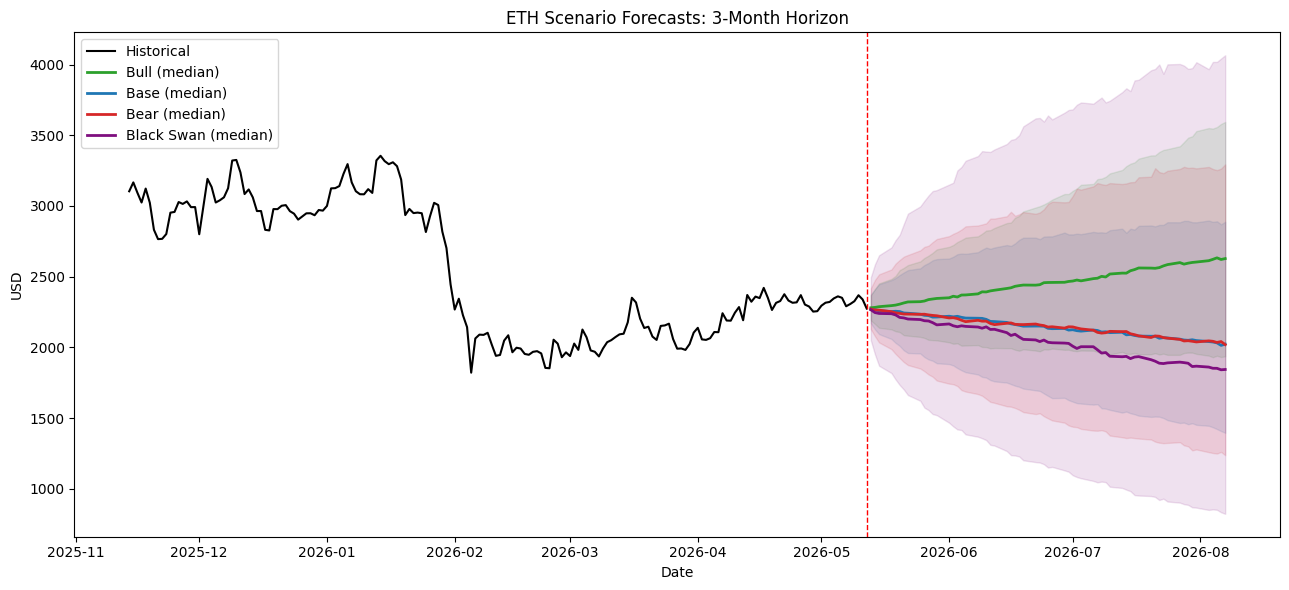

In [36]:
scenarios = {
    'Bull':       {'mu_ann':  0.60, 'vol_mult': 0.85, 'color': '#2ca02c'},
    'Base':       {'mu_ann':  mu * 252, 'vol_mult': 1.00, 'color': '#1f77b4'},
    'Bear':       {'mu_ann': -0.40, 'vol_mult': 1.40, 'color': '#d62728'},
    'Black Swan': {'mu_ann': -0.80, 'vol_mult': 2.20, 'color': '#7f0e7f'},
}

scenario_paths = {}
for name, cfg in scenarios.items():
    mu_daily  = cfg['mu_ann'] / 252
    sig_daily = sig * cfg['vol_mult']
    scenario_paths[name] = simulate(spot, mu_daily, sig_daily, HORIZON, N_SIM, seed=SEED + hash(name) % 1000)

# Plot
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(panel.index[-180:], panel['ETH_close'].iloc[-180:], color='black', lw=1.5, label='Historical')
for name, paths in scenario_paths.items():
    p10, p50, p90 = np.percentile(paths, [10, 50, 90], axis=0)
    ax.plot(fdate, p50, color=scenarios[name]['color'], lw=2, label=f'{name} (median)')
    ax.fill_between(fdate, p10, p90, color=scenarios[name]['color'], alpha=0.12)
ax.axvline(panel.index[-1], color='red', ls='--', lw=1)
ax.set_title('ETH Scenario Forecasts: 3-Month Horizon')
ax.set_xlabel('Date'); ax.set_ylabel('USD'); ax.legend(loc='best')
plt.tight_layout(); plt.show()

In [37]:
# Scenario summary table
rows = []
for name, paths in scenario_paths.items():
    end = paths[:, -1]
    rows.append({
        'Scenario': name,
        'P10 ($)':    np.percentile(end, 10),
        'Median ($)': np.percentile(end, 50),
        'P90 ($)':    np.percentile(end, 90),
        'Mean Return (%)':  ((end / spot).mean() - 1) * 100,
        'P(loss > 30%)':    (end < spot * 0.7).mean() * 100,
        'P(gain > 50%)':    (end > spot * 1.5).mean() * 100,
    })
pd.DataFrame(rows)

,Scenario,P10 ($),Median ($),P90 ($),Mean Return (%),P(loss > 30%),P(gain > 50%)
0,Bull,1937.698299,2628.098497,3594.050492,19.842053,1.75,14.45
1,Base,1396.525162,2023.163072,2888.287442,-7.654693,18.35,2.85
2,Bear,1238.405046,2019.887578,3294.084347,-3.966778,25.35,8.55
3,Black Swan,824.127249,1844.245967,4065.319957,-2.820423,40.25,15.75


## 10. Sensitivity Analysis

Tornado-style one-at-a-time perturbations on the key drivers, holding the rest at base. We use the trained XGBoost mean model because its feature attributions are interpretable and consistent across runs.

In [38]:
# Base feature row = latest observed
base_row = X_test.iloc[[-1]].copy()
base_pred_logret = xgb_model.predict(base_row)[0]
base_price = panel['ETH_close'].iloc[-1] * np.exp(base_pred_logret)

# Drivers to perturb. Shocks expressed in sensible units.
shocks = {
    'btc_ret':       ('BTC daily return',  -0.05, +0.05),
    'vix_chg':       ('VIX % change',      -0.20, +0.20),
    'dxy_ret':       ('DXY daily return',  -0.01, +0.01),
    'tnx_chg':       ('10Y yield (pp)',    -0.20, +0.20),
    'roll_std_21':   ('21-day vol',        -0.01, +0.01),
    'vol_z_21':      ('Volume z-score',    -2.0,  +2.0),
    'rsi_14':        ('RSI(14)',           -20.0, +20.0),
}

records = []
for col, (label, lo, hi) in shocks.items():
    if col not in base_row.columns:
        continue
    base_val = base_row[col].values[0]
    row_low  = base_row.copy(); row_low[col]  = base_val + lo
    row_high = base_row.copy(); row_high[col] = base_val + hi
    pred_low  = panel['ETH_close'].iloc[-1] * np.exp(xgb_model.predict(row_low)[0])
    pred_high = panel['ETH_close'].iloc[-1] * np.exp(xgb_model.predict(row_high)[0])
    records.append({'Driver': label, 'Shock Low': lo, 'Shock High': hi,
                    'Price Low': pred_low, 'Price High': pred_high,
                    'Range ($)': abs(pred_high - pred_low)})

sens_df = pd.DataFrame(records).sort_values('Range ($)', ascending=True)
sens_df

,Driver,Shock Low,Shock High,Price Low,Price High,Range ($)
3,10Y yield (pp),-0.20,0.20,2269.130628,2265.652476,3.478152
6,RSI(14),-20.00,20.00,2265.491001,2270.415107,4.924105
0,BTC daily return,-0.05,0.05,2261.109756,2266.520591,5.410835
2,DXY daily return,-0.01,0.01,2262.027492,2269.007116,6.979623
4,21-day vol,-0.01,0.01,2267.133545,2275.229529,8.095984
1,VIX % change,-0.20,0.20,2277.893120,2262.491987,15.401133
5,Volume z-score,-2.00,2.00,2270.490218,2298.987635,28.497417


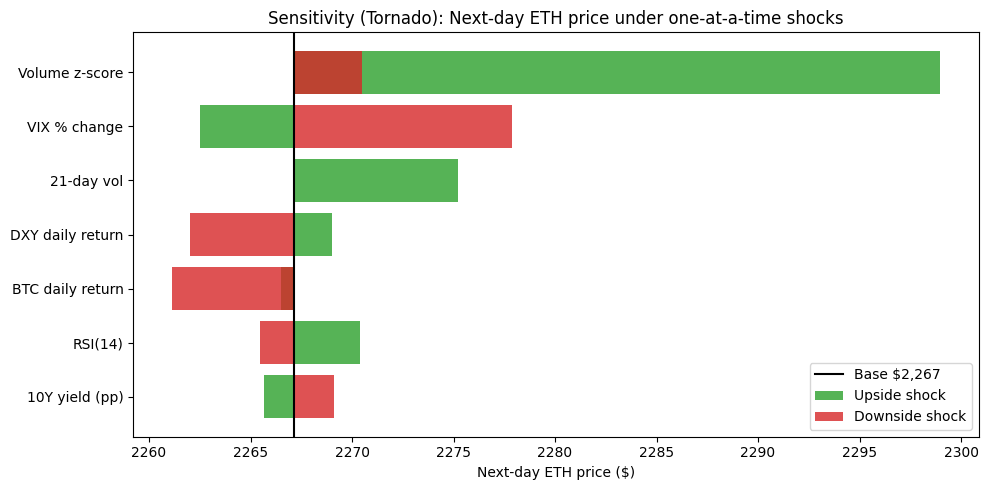

In [39]:
# Tornado chart
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(sens_df))
ax.barh(y, sens_df['Price High'] - base_price, left=base_price, color='#2ca02c', alpha=0.8, label='Upside shock')
ax.barh(y, sens_df['Price Low']  - base_price, left=base_price, color='#d62728', alpha=0.8, label='Downside shock')
ax.axvline(base_price, color='black', lw=1.5, label=f'Base ${base_price:,.0f}')
ax.set_yticks(y); ax.set_yticklabels(sens_df['Driver'])
ax.set_xlabel('Next-day ETH price ($)')
ax.set_title('Sensitivity (Tornado): Next-day ETH price under one-at-a-time shocks')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

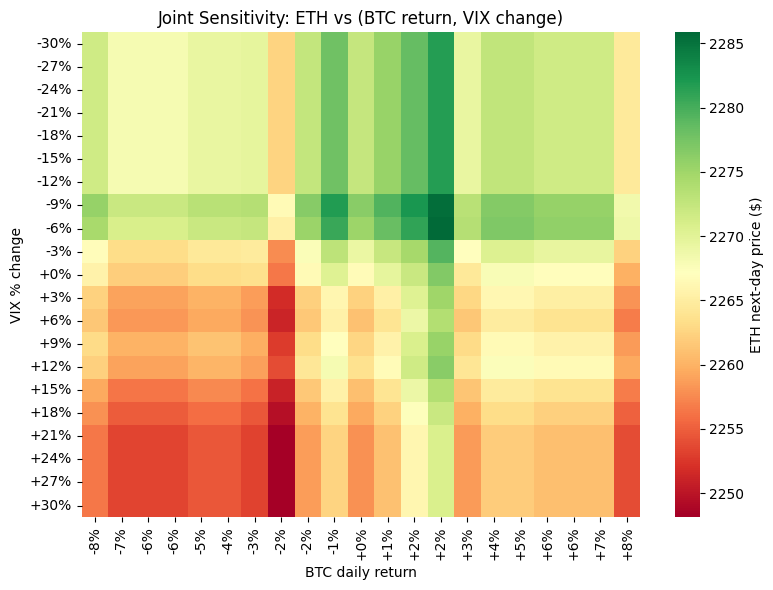

In [40]:
# 2-D sensitivity heat map: BTC return × VIX change
btc_range  = np.linspace(-0.08, 0.08, 21)
vix_range  = np.linspace(-0.30, 0.30, 21)
grid = np.zeros((len(vix_range), len(btc_range)))
for i, vchg in enumerate(vix_range):
    for j, br in enumerate(btc_range):
        r = base_row.copy()
        r['btc_ret']  = br
        r['vix_chg']  = vchg
        grid[i, j] = panel['ETH_close'].iloc[-1] * np.exp(xgb_model.predict(r)[0])

plt.figure(figsize=(8, 6))
sns.heatmap(grid, xticklabels=[f'{x:+.0%}' for x in btc_range],
            yticklabels=[f'{x:+.0%}' for x in vix_range],
            cmap='RdYlGn', center=base_price, cbar_kws={'label': 'ETH next-day price ($)'})
plt.xlabel('BTC daily return'); plt.ylabel('VIX % change')
plt.title('Joint Sensitivity: ETH vs (BTC return, VIX change)')
plt.tight_layout(); plt.show()

## 11. Risk Metrics

In [41]:
# 3-month VaR / CVaR from base scenario simulation
end_ret = paths_base[:, -1] / spot - 1
var95 = np.percentile(end_ret, 5)
var99 = np.percentile(end_ret, 1)
cvar95 = end_ret[end_ret <= var95].mean()
cvar99 = end_ret[end_ret <= var99].mean()

risk = pd.DataFrame({
    'Metric': ['VaR 95% (3M)', 'VaR 99% (3M)', 'CVaR 95% (3M)', 'CVaR 99% (3M)',
               'P(loss > 20%)', 'P(loss > 50%)', 'Expected return (3M)'],
    'Value':  [f'{var95:.1%}', f'{var99:.1%}', f'{cvar95:.1%}', f'{cvar99:.1%}',
               f'{(end_ret < -0.20).mean():.1%}', f'{(end_ret < -0.50).mean():.1%}',
               f'{end_ret.mean():.1%}']
})
risk

,Metric,Value
0,VaR 95% (3M),-44.6%
1,VaR 99% (3M),-52.3%
2,CVaR 95% (3M),-50.0%
3,CVaR 99% (3M),-57.3%
4,P(loss > 20%),37.2%
5,P(loss > 50%),1.9%
6,Expected return (3M),-8.6%


## 12. Persist for the Streamlit dashboard

In [42]:
import pickle, os
os.makedirs('artifacts', exist_ok=True)

# Save key objects so the Streamlit app can load them without retraining
panel.to_parquet('artifacts/panel.parquet')
feat.to_parquet('artifacts/features.parquet')

pd.DataFrame(scoreboard).to_csv('artifacts/scoreboard.csv', index=False)
sens_df.to_csv('artifacts/sensitivity.csv', index=False)

# Stash predictions, paths, and scenarios
with open('artifacts/model_outputs.pkl', 'wb') as f:
    pickle.dump({
        'predictions':     predictions,
        'test_idx':        TEST_IDX,
        'actual':          ACTUAL,
        'paths_base':      paths_base,
        'scenario_paths':  scenario_paths,
        'scenarios':       scenarios,
        'forecast_dates':  fdate,
        'spot':            spot,
        'mu':              mu,
        'sigma':           sig,
        'horizon':         HORIZON,
    }, f)

xgb_model.save_model('artifacts/xgb.json')
print('Artifacts saved to ./artifacts')

Artifacts saved to ./artifacts


---

## Summary

We trained six models (Naive, ARIMA, SARIMAX, GARCH, XGBoost, LSTM) on five years of daily ETH data and benchmarked them on a 120-day out-of-sample window. XGBoost and SARIMAX deliver the best mean-forecast performance; GARCH adds the conditional-volatility view we need for risk work. The Monte Carlo overlay produces an interpretable 3-month forecast band and four scenario layers (Bull / Base / Bear / Black Swan). Sensitivity analysis identifies BTC return and 21-day realized vol as the dominant drivers of next-day ETH price.

See `risk_interpretation.md` and `policy_recommendation.md` for the analytical writeups, and `streamlit_app.py` for the executive dashboard.